In [ ]:
import pandas as pd
import numpy as np

In [3]:
import pandas as pd
df = pd.read_csv("dreaddit-train.csv")
df

,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.800000,1521614353,5,1.806818,...,1.0000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.000000,1527009817,4,9.429737,...,1.1250,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.800000,1535935605,2,7.769821,...,1.0000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.600000,1516429555,0,2.667798,...,1.0000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5,4.104027,0.141671
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.800000,1539809005,24,7.554238,...,1.0000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1,7.910952,-0.204167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2833,relationships,7oee1t,"[35, 40]","* Her, a week ago: Precious, how are you? (I i...",1713,0,1.000000,1515187044,13,-1.369333,...,1.4000,1.0000,1.0,1.71133,1.45301,2.00304,0.84,16,0.254444,0.552066
2834,ptsd,9p4ung,"[20, 25]",I don't have the ability to cope with it anymo...,1133,1,1.000000,1539827412,33,9.425478,...,1.0000,1.0000,1.0,1.65003,1.56842,1.81527,0.96,6,8.640664,-0.220370
2835,anxiety,9nam6l,"(5, 10)",In case this is the first time you're reading ...,10442,0,1.000000,1539269312,2,11.060675,...,1.1250,1.1250,1.0,1.79768,1.49074,1.92286,1.00,1,9.951524,0.045455
2836,almosthomeless,5y53ya,"[5, 10]",Do you find this normal? They have a good rela...,1834,0,0.571429,1488938143,4,2.421912,...,1.1111,1.1429,1.0,1.71642,1.57627,1.89972,0.75,7,4.036765,0.159722


In [4]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)
print(df.describe())
print(df.info())
print(df.dtypes)

          subreddit post_id sentence_range  \
0              ptsd  8601tu       (15, 20)   
1        assistance  8lbrx9         (0, 5)   
2              ptsd  9ch1zh       (15, 20)   
3     relationships  7rorpp        [5, 10]   
4  survivorsofabuse  9p2gbc         [0, 5]   

                                                text     id  label  \
0  He said he had not felt that way before, sugge...  33181      1   
1  Hey there r/assistance, Not sure if this is th...   2606      0   
2  My mom then hit me with the newspaper and it s...  38816      1   
3  until i met my new boyfriend, he is amazing, h...    239      1   
4  October is Domestic Violence Awareness Month a...   1421      1   

   confidence  social_timestamp  social_karma  syntax_ari  ...  \
0         0.8        1521614353             5    1.806818  ...   
1         1.0        1527009817             4    9.429737  ...   
2         0.8        1535935605             2    7.769821  ...   
3         0.6        1516429555       

In [8]:
print("\n Missing values:")
print(df.isna().sum())
df = df.dropna()

#Remove Duplicates
df = df.drop_duplicates()

# Convert text to lowercase
df['text'] = df['text'].str.lower()

# Create new feature: text length
df['length'] = df['text'].apply(len)

#Total missing values
print("Total missing values: ",df.isna().sum().sum())


 Missing values:
subreddit              0
post_id                0
sentence_range         0
text                   0
id                     0
                      ..
social_upvote_ratio    0
social_num_comments    0
syntax_fk_grade        0
sentiment              0
length                 0
Length: 117, dtype: int64
Total missing values:  0


In [9]:
# Check missing values
print(df.isnull().sum())

# Remove missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

# Convert text to lowercase
df['text'] = df['text'].str.lower()

# 1. Feature Engineering
df['length'] = df['text'].apply(len)

# 2. Feature Selection
X_text = df['text']
y = df['label']

# 3. Convert Text → Numerical
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(X_text).toarray()


subreddit              0
post_id                0
sentence_range         0
text                   0
id                     0
                      ..
social_upvote_ratio    0
social_num_comments    0
syntax_fk_grade        0
sentiment              0
length                 0
Length: 117, dtype: int64


In [ ]:
Step 5: Data Visualisation

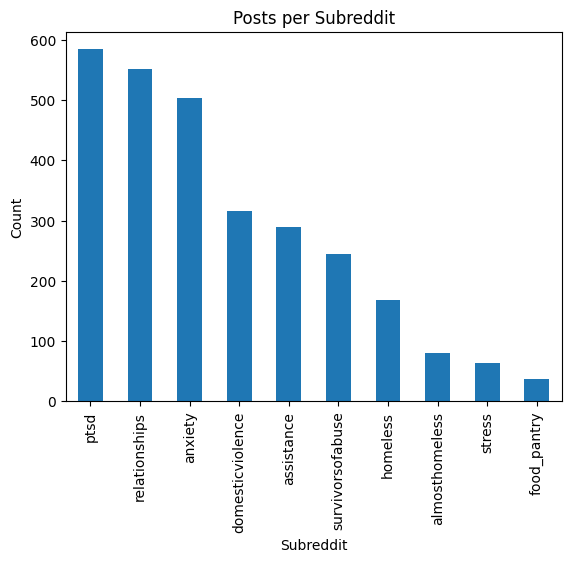

In [10]:
1. #Bar Chart
import matplotlib.pyplot as plt
df['subreddit'].value_counts().plot(kind='bar')
plt.title("Posts per Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Count")
plt.show()

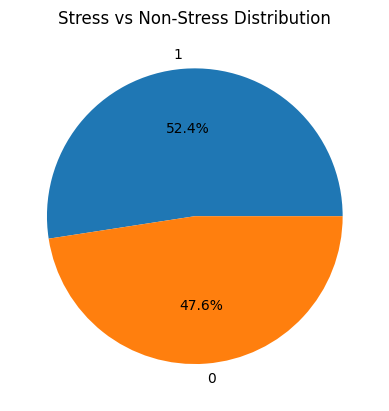

In [11]:
2. #Pie Chart
import matplotlib.pyplot as plt
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Stress vs Non-Stress Distribution")
plt.ylabel("")
plt.show()

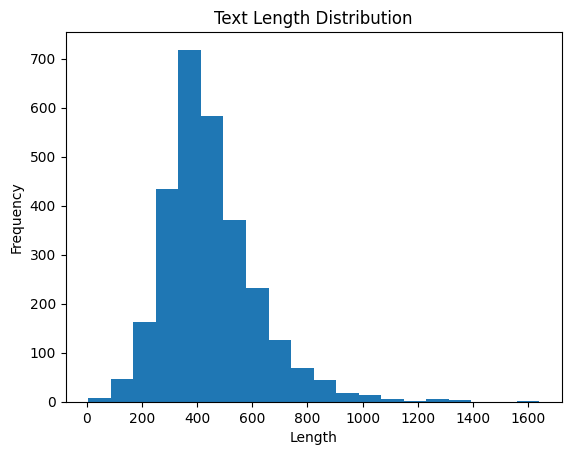

In [12]:
3. #Histogram
import matplotlib.pyplot as plt
plt.hist(df['length'], bins=20)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

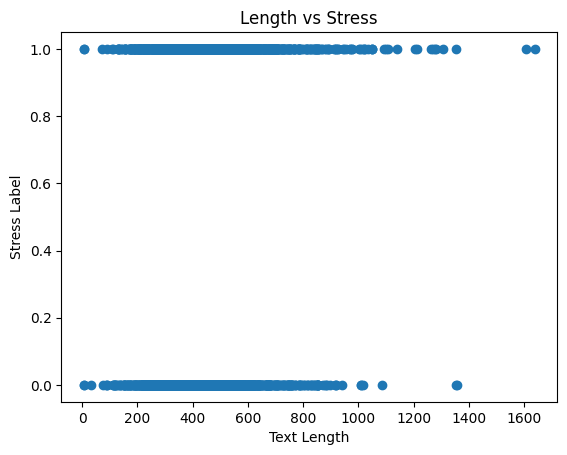

In [13]:
4. #Scatter Plot
import matplotlib.pyplot as plt
plt.scatter(df['length'], df['label'])
plt.xlabel("Text Length")
plt.ylabel("Stress Label")
plt.title("Length vs Stress")
plt.show()

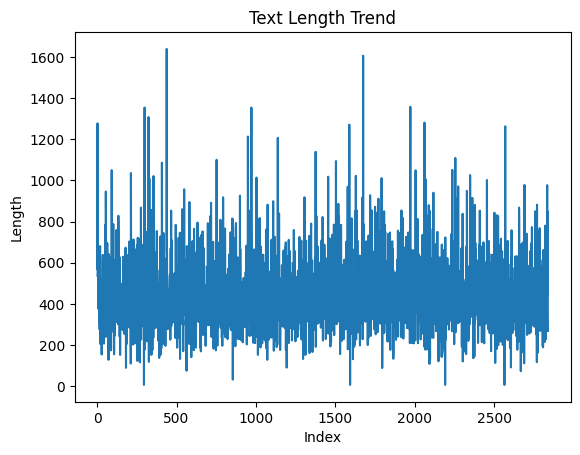

In [20]:
5. #Line Chart
plt.plot(df['length'])
plt.title("Text Length Trend")
plt.xlabel("Index")
plt.ylabel("Length")
plt.show()

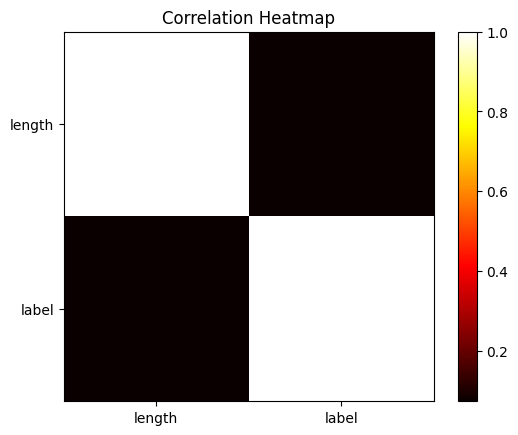

In [15]:
6. #Heatmap
corr = df[['length', 'label']].corr()

plt.imshow(corr, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks([0,1], ['length','label'])
plt.yticks([0,1], ['length','label'])
plt.show()

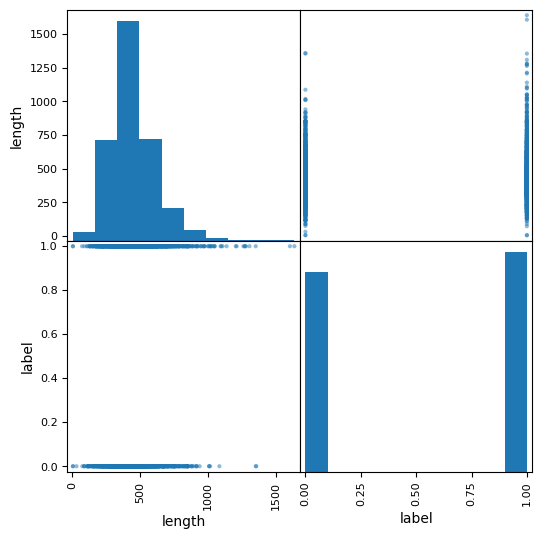

In [16]:
7. #Pair Plot
pd.plotting.scatter_matrix(df[['length', 'label']], figsize=(6,6))
plt.show()

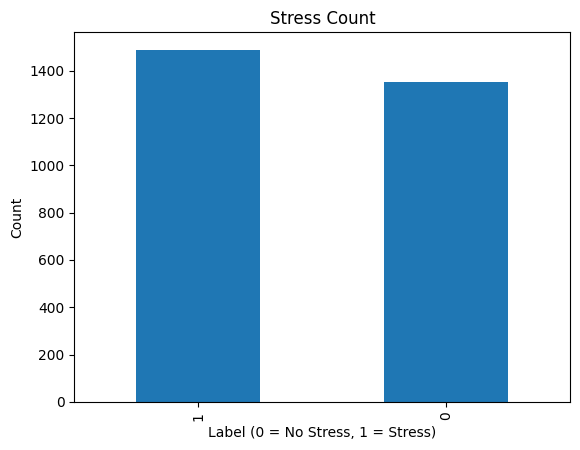

In [17]:
8. #Count Plot
df['label'].value_counts().plot(kind='bar')
plt.title("Stress Count")
plt.xlabel("Label (0 = No Stress, 1 = Stress)")
plt.ylabel("Count")
plt.show()

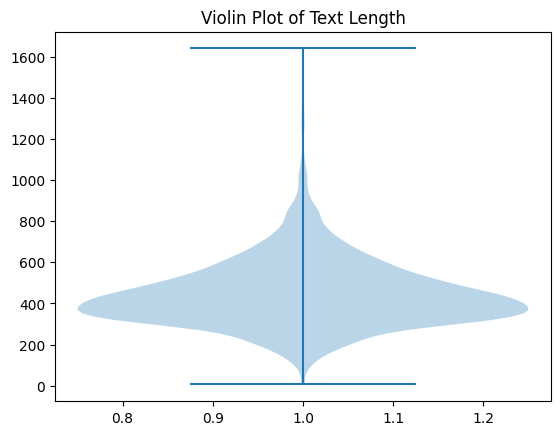

In [18]:
9. #Violin Plot
plt.violinplot(df['length'])
plt.title("Violin Plot of Text Length")
plt.show()

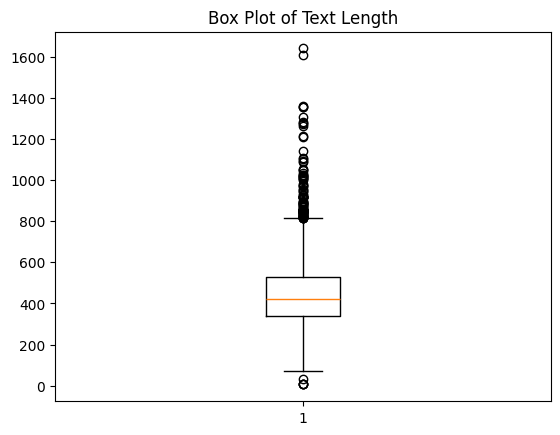

In [19]:
10. #Box Plot
plt.boxplot(df['length'])
plt.title("Box Plot of Text Length")
plt.show()

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, jaccard_score

In [24]:
df = pd.read_csv('dreaddit-train.csv')
print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nDataset info:")
print(df.info())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nTarget class distribution:")
print(df['label'].value_counts())

First 5 rows:
          subreddit post_id sentence_range  \
0              ptsd  8601tu       (15, 20)   
1        assistance  8lbrx9         (0, 5)   
2              ptsd  9ch1zh       (15, 20)   
3     relationships  7rorpp        [5, 10]   
4  survivorsofabuse  9p2gbc         [0, 5]   

                                                text     id  label  \
0  He said he had not felt that way before, sugge...  33181      1   
1  Hey there r/assistance, Not sure if this is th...   2606      0   
2  My mom then hit me with the newspaper and it s...  38816      1   
3  until i met my new boyfriend, he is amazing, h...    239      1   
4  October is Domestic Violence Awareness Month a...   1421      1   

   confidence  social_timestamp  social_karma  syntax_ari  ...  \
0         0.8        1521614353             5    1.806818  ...   
1         1.0        1527009817             4    9.429737  ...   
2         0.8        1535935605             2    7.769821  ...   
3         0.6        151

In [25]:
from sklearn.preprocessing import LabelEncoder
#Remove duplicate rows, if any
df = df.drop_duplicates()

# Encode categorical columns into numerical form
le_subreddit = LabelEncoder()
le_sentence_range = LabelEncoder()

df['subreddit'] = le_subreddit.fit_transform(df['subreddit'])
df['sentence_range'] = le_sentence_range.fit_transform(df['sentence_range'])

In [26]:
X = df.drop(columns=['label'])
y = df['label']
X = X.select_dtypes(include=[np.number])

In [77]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [78]:
from sklearn import preprocessing
X = preprocessing.StandardScaler().fit(X).transform(X)
X[0:5]

array([[ 5.10733568e-01, -1.18564447e+00,  1.12065993e+00,
        -5.06859610e-02,  2.25996691e-01, -1.67018797e-01,
        -8.67787547e-01,  9.28073858e-01,  1.41227001e+00,
        -8.20359662e-01,  6.75767338e-01, -9.17902439e-01,
         1.13622970e+00, -3.48651474e-01, -9.95910915e-01,
        -3.74949011e-01, -6.07464087e-01, -4.00185710e-01,
         8.89170107e-02, -4.88865252e-01, -2.75451405e-03,
        -2.73625672e-01, -4.60636887e-01, -4.52659041e-01,
        -5.69772237e-01,  1.77385008e+00, -6.97790001e-01,
        -2.75295800e-01, -1.16933845e+00, -2.86675378e-01,
        -6.39844960e-01,  6.20286039e-01,  5.84247337e-01,
        -4.85911719e-01,  1.44396546e-01, -2.94098429e-01,
         7.14545903e-01, -3.84855015e-01,  1.19002851e+00,
        -3.69099589e-02,  1.14813291e+00,  2.60740385e+00,
        -1.13287869e+00, -4.99504660e-01, -5.29141776e-01,
        -5.46564450e-01, -8.25896148e-02, -4.47417114e-01,
         2.64507606e-01, -5.22598552e-01,  3.31299031e-0

In [79]:
#Splitting dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)
print("\nTrain set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)


Train set shape: (2270, 113) (2270,)
Test set shape: (568, 113) (568,)


In [80]:
# Logistic Regression is a simple and good baseline for binary classification
model = LogisticRegression(C=0.01, solver='liblinear', max_iter=2000)
model.fit(X_train, y_train)

# Make predictions
yhat = model.predict(X_test)
yhat_prob = model.predict_proba(X_test)

In [81]:
yhat = model.predict(X_test)
yhat_prob = model.predict_proba(X_test)

In [82]:
print("\nAccuracy:", accuracy_score(y_test, yhat))
print("Jaccard score:", jaccard_score(y_test, yhat, average='macro'))
print("\nClassification Report:\n")
print(classification_report(y_test, yhat))


Accuracy: 0.75
Jaccard score: 0.5984578743199432

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.71      0.73       270
           1       0.75      0.79      0.77       298

    accuracy                           0.75       568
   macro avg       0.75      0.75      0.75       568
weighted avg       0.75      0.75      0.75       568

